<a href="https://colab.research.google.com/github/SLIIT-SE-Evenza/AIML-Project-NASDAQ-Stock-Price-Trend-Predictor/blob/main/NASDAQ_CAT_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing libraries

In [13]:
# Used for importing dataset from Kaggle
import kagglehub

# Used for getting the files and creating the full paths
import os

# Data Manipulation Tools
import pandas as pd
import numpy as np

# Scalar
from sklearn.preprocessing import RobustScaler

# Classifier
from sklearn.dummy import DummyClassifier

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report)

# Data Visualization Tools
import seaborn as sns
import matplotlib.pyplot as plt

# Will display the plot below the code
%matplotlib inline

sns.set(color_codes = True)

RANDOM_STATE = 42

# Importing the dataset from Kaggle

In [14]:
# Download latest version
path = kagglehub.dataset_download("jacksoncrow/stock-market-dataset")

print("Path to dataset files:", path)

100%|██████████| 522M/522M [00:04<00:00, 135MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jacksoncrow/stock-market-dataset/versions/2


## Listing the files that are in the dataset folder

In [15]:
# List files in the download directory
print("Files in the dataset directory:")
for file in os.listdir(path):
  print(file)

Files in the dataset directory:
stocks
etfs
symbols_valid_meta.csv


## Loading & Displaying the `CAT.csv` file

In [16]:
cat_file = os.path.join(path, 'stocks', 'CAT.csv')
df = pd.read_csv(cat_file)

# Displaying the first 5 rows
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1962-01-02,1.604167,1.619792,1.588542,1.604167,0.136957,163200.0
1,1962-01-03,1.604167,1.619792,1.588542,1.619792,0.138291,156000.0
2,1962-01-04,1.656250,1.708333,1.656250,1.661458,0.141849,355200.0
3,1962-01-05,1.661458,1.697917,1.656250,1.677083,0.143183,163200.0
4,1962-01-08,1.677083,1.703125,1.666667,1.687500,0.144072,204000.0


# Data Analysis

## Check for the Types of the Data in the Dataset

In [17]:
df.dtypes

,0
Date,object
Open,float64
High,float64
Low,float64
Close,float64
Adj Close,float64
Volume,float64


Here, there are no categorical columns. All are numerical columns only. So, no encoding is required.

## Checking the first 5 rows

In [18]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1962-01-02,1.604167,1.619792,1.588542,1.604167,0.136957,163200.0
1,1962-01-03,1.604167,1.619792,1.588542,1.619792,0.138291,156000.0
2,1962-01-04,1.656250,1.708333,1.656250,1.661458,0.141849,355200.0
3,1962-01-05,1.661458,1.697917,1.656250,1.677083,0.143183,163200.0
4,1962-01-08,1.677083,1.703125,1.666667,1.687500,0.144072,204000.0


# Data Preprocessing

## Date Handling

It does three things:

- **`pd.to_datetime`** converts the `Date` column from strings (`object`) into real datetime values, which you need for sorting, date-based splits, and plotting by date.
- **`sort_values('Date')`** puts the rows in chronological order.
- **`reset_index(drop=True)`** rebuilds a clean 0..n−1 index after sorting and discards the old one.

<br>

> A **chronological split** means training on the past and testing on the future. Most code does that by position, not by looking at the dates, so the row order has to be correct first.

<br>

## What goes wrong with unsorted rows

Suppose the rows were shuffled or out of order, for example with 2015 rows mixed in among 1970 rows. The first 80% of rows would then contain a random mix of old and recent dates, and the test set would too.

That causes two problems:

1. **Future leaks into training.** The model could train on 2018 prices and then be tested on 2016, which is predicting the past from the future. Real trading never allows that.
2. **Scores look better than they are.** Neighboring days have very similar prices, so a model that has seen the days around a test day can nearly interpolate it. The test result would be overly optimistic and would not reflect real forecasting ability.

<br>

## Why your sorting code matters

Your `sort_values('Date')` line guarantees that row position matches time order, so all of the above behave correctly. The simplest safety net is to sort once at the start (as you did) and keep the rows in that order for the rest of the notebook.

In [19]:
# Convert Date and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("Updated data types:")
print(df.dtypes)
print("\nFirst date:", df['Date'].min())
print("Last date:", df['Date'].max())

Updated data types:
Date         datetime64[ns]
Open                float64
High                float64
Low                 float64
Close               float64
Adj Close           float64
Volume              float64
dtype: object

First date: 1962-01-02 00:00:00
Last date: 2020-04-01 00:00:00


## Remove the irrelevant columns

**Why dropping it makes sense**
- `Close` and `Adj Close` carry almost the same information. They differ only by a dividend adjustment factor that grows as we go further back in time, so keeping both adds redundancy (multicollinearity) without adding signal.
  - "Without adding signal" means the extra column doesn't give the model any new, useful information to learn from.
- `Adj Close` is the better one to keep for modeling because it reflects total return. A raw `Close` shows artificial drops on dividend dates, which a model could mistake for real price moves.

<br>

**What it leaves unresolved**
Once `Close` is gone, `Open`, `High`, and `Low` are still on the raw price scale while `Adj Close` is on the adjusted scale. That's the mismatch I mentioned before (1.60 versus 0.137 in the first row). We can fix it by putting all four on the adjusted scale, using the factor we already have in the data:

<br>

$$f_t = \frac{\text{Adj Close}_t}{\text{Close}_t}, \qquad \text{Open}^{adj}_t = f_t \cdot \text{Open}_t$$

<br>

The order matters here. If we drop `Close` first, we lose the information needed to compute the factor.

<br>

**One caveat**

Whether dropping it is right also depends on our prediction target. If we're predicting the next day's price or trend direction, build the target from `Adj Close` (for example, the next day's return), so features and target stay on the same basis.

So I'd keep dropping `Close`, but move the drop after the adjustment step.

In [20]:
factor = df['Adj Close'] / df['Close']

for col in ['Open', 'High', 'Low']:
    df[col] = df[col] * factor

df = df.drop(columns=['Close'])

In [21]:
df.head()

,Date,Open,High,Low,Adj Close,Volume
0,1962-01-02,0.136957,0.138291,0.135623,0.136957,163200.0
1,1962-01-03,0.136957,0.138291,0.135623,0.138291,156000.0
2,1962-01-04,0.141404,0.145851,0.141404,0.141849,355200.0
3,1962-01-05,0.141849,0.144961,0.141404,0.143183,163200.0
4,1962-01-08,0.143183,0.145406,0.142293,0.144072,204000.0


### Display column names

In [22]:
print(list(df.columns))

['Date', 'Open', 'High', 'Low', 'Adj Close', 'Volume']


## Check for Duplicate Rows

In [23]:
df.shape    # Checks the dimension of the DataFrame

(14665, 6)

In [24]:
df.count()  # Counts the number of rows

,0
Date,14665
Open,14663
High,14663
Low,14663
Adj Close,14663
Volume,14663


`df.duplicated()`

This returns a **Boolean Series (True/False)** indicating whether each row in the DataFrame is a duplicate of a previous row.

`df[df.duplicated()]`

This filters the DataFrame and returns only the rows that are duplicates (excluding the first instance).

`duplicate_rows_df.shape`

This returns the shape of the new DataFrame (**number of duplicate rows**, **number of columns**).

In [25]:
duplicate_rows_df = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_df.shape)

number of duplicate rows:  (0, 6)


In [26]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


## Handling Missing or Null Values

In [27]:
print(df.isnull().sum())    # Determines the number of missing values in the dataset

Date         0
Open         2
High         2
Low          2
Adj Close    2
Volume       2
dtype: int64


### Disadvantages of Filling w. Zero & w. Average (Mean)

Replacing missing stock values with a static 0 or the overall dataset average is technically executable in Python, but both methods are highly detrimental to financial time-series modeling.

#### Disadvantages of Filling with Zero

* **Artificial Crashes:** A stock price of $0 fundamentally dictates that the asset is entirely worthless. Inserting a 0 creates an immediate, catastrophic 100% price drop in your dataset.
* **Distorted Volatility:** Your machine learning algorithm will attempt to learn from this synthetic crash, which will severely skew technical indicators and any momentum features you calculate later, such as Daily Returns.

#### Disadvantages of Filling with the Average (Mean)

* **Trend Destruction:** Financial data is strictly chronological. If a stock averages \$50 over a five-year period, inserting that \$50 into a missing day during a bull market where the stock was trading at \$150 creates an artificial \$100 plunge.
* **Data Leakage:** Calculating a mean requires aggregating the entire dataset. If you use future prices to calculate an average to fill a past gap, you leak future information into the past, entirely invalidating the model's predictive integrity.

In [28]:
# Inspect the rows that will be removed
print(df[df.isna().any(axis=1)])

            Date  Open  High  Low  Adj Close  Volume
8378  1995-04-14   NaN   NaN  NaN        NaN     NaN
13605 2016-01-18   NaN   NaN  NaN        NaN     NaN


These two rows are market holidays. Both dates fall on days when US exchanges were closed:

- **1995-04-14** was Good Friday.
- **2016-01-18** was Martin Luther King Jr. Day.

**What this means for your fill decision**:

- No trading happened on these days. The price didn't change because the market was closed, not because data went missing.
- Dropping is the more accurate choice. Forward fill would create two fake trading days, each with a 0% return and a copy of the previous day's Volume, as if shares had traded.
- Dropping is harmless to the sequence. Both rows are isolated and mid-series (index 8378 and 13605), and the surrounding days stay in the correct order. The next trading day's return is simply measured against the last real close.

In [29]:
print("Rows before dropping:", df.shape[0])

# Drop rows with missing values and rebuild a clean 0..n-1 index
df = df.dropna().reset_index(drop=True)

# Verify
print("\nRemaining rows (after dropping):", df.shape[0])
print("Total missing values:", df.isnull().sum().sum())

Rows before dropping: 14665

Remaining rows (after dropping): 14663
Total missing values: 0


### Why We Drop the Missing Rows Instead of Forward Filling

The 2 rows with missing values (1995-04-14 and 2016-01-18) are **market holidays** (Good Friday and Martin Luther King Jr. Day). Every price and volume column is empty in both rows because the exchange was closed and **no trading took place**. This is not missing data that needs to be recovered.

**Reasons for dropping them**

- **No real trading day exists.** Forward filling would create two days that never happened. Dropping the rows leaves only genuine trading days.
- **Forward filling creates false zero returns.** Carrying the previous price forward makes the daily return on the filled day exactly zero:

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}} = 0 \quad \text{when } P_t = P_{t-1}$$

  This understates volatility and slightly distorts features built from returns, such as moving averages and momentum indicators.

- **Forward filling invents trading volume.** It copies the previous day's `Volume` into a day when no shares were traded, which is false information.
- **Dropping does not break the time series.** The dataset already excludes weekends and holidays, so it is ordered by trading day rather than by calendar day. Removing 2 isolated rows out of 14,665 keeps the remaining data in correct chronological order. The next trading day's return is measured against the last real closing price.
- **Dropping causes no leakage.** Forward fill is also leakage-safe, but only dropping avoids adding any artificial values at all.

**Conclusion:** Only 2 of 14,665 rows (about 0.014%) are affected, so the impact on results is minimal either way. However, dropping is the more accurate choice because it keeps only real trading days.

In [30]:
print(df.isnull().sum())

Date         0
Open         0
High         0
Low          0
Adj Close    0
Volume       0
dtype: int64


## Outliers: keep them

Raw prices trend upward for decades, so an IQR rule flags recent (real) prices as outliers
and capping them would distort the history. The most extreme daily returns fall on known
market events (Black Monday 1987, the 2008 crisis, COVID in March 2020) and persist in the
following days, so they are genuine observations. No rows are removed or capped.
`RobustScaler` limits their influence during scaling.

In [31]:
#IQR outlier counts
summary = {}

for col in ['Open', 'High', 'Low', 'Adj Close', 'Volume']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    summary[col] = count
    print(f"{col}: {count} possible outliers")

Open: 1505 possible outliers
High: 1490 possible outliers
Low: 1500 possible outliers
Adj Close: 1497 possible outliers
Volume: 489 possible outliers


### Handling the outliers

For this dataset, the best method is probably **not capping the price columns at all**. Instead, transform the prices into returns first, and only then check for outliers.

---

**Why the IQR method doesn't suit raw prices**

IQR assumes the data are roughly stationary. CAT's price rose from about 0.14 to about 162 over 58 years, so the IQR bounds treat the recent high-price years as abnormal. That's why about 1,500 rows (roughly 10%) were flagged per price column, and capping them cut your maximum `Adj Close` from about 162 to about 73. Those rows are real prices, not errors.

---

**Recommended approach**

1. **Convert prices to returns.** Returns are roughly stationary, so outlier detection means something on them:

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}}, \qquad \text{or} \qquad r_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right)$$

2. **Separate errors from real events.** A genuinely extreme return (the October 1987 crash, 2008, March 2020) is exactly what a model of price movement should learn from. Remove or fix only values that are impossible, such as:
   - zero or negative prices
   - `High < Low`
   - a one-day jump that reverses the next day (a likely data error)

3. **If you still want robustness, winsorize returns, not prices,** using bounds computed on the training set only:

$$\text{lower} = Q_{0.01}(r_{train}), \qquad \text{upper} = Q_{0.99}(r_{train})$$

4. **Keep the log transform on Volume.** Your `np.log1p` step was a good choice because volume is heavily right-skewed.

#### Calculating the return value column

In [32]:
df['Return'] = df['Adj Close'].pct_change()
df['Log_Volume'] = np.log1p(df['Volume'])
df = df.dropna().reset_index(drop=True)

`pct_change()` has no previous day to compare against for the first row, so it sets `Return` to `NaN` there. That's the 1962-01-02 row. The `dropna()` in that snippet removes it, and `reset_index(drop=True)` rebuilds a clean index afterwards.

<br>

If you skip it, the `NaN` in `Return` can cause problems later:

- `nlargest` and `nsmallest` would skip it, but the quantile bounds for winsorizing would be fine, while any model or scaler you fit would raise an error on `NaN` input.
- Your first training row would be unusable.

---

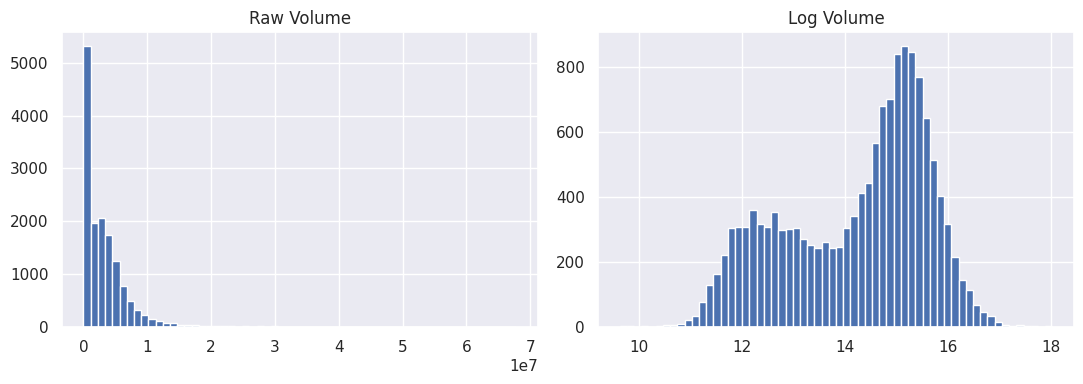

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["Volume"], bins=60)
axes[0].set_title("Raw Volume")
axes[1].hist(df["Log_Volume"], bins=60)
axes[1].set_title("Log Volume")
plt.tight_layout()
plt.show()

Trading volume is heavily right-skewed, so a log transform (log1p) was applied to compress extreme spikes and make the distribution closer to symmetric. The day-to-day change in log volume represents the percentage change in trading activity.

#### Check for impossible values (data errors)

In [34]:
print("Non-positive prices:", (df[['Open','High','Low','Adj Close']] <= 0).any(axis=1).sum())
print("High < Low:", (df['High'] < df['Low']).sum())

Non-positive prices: 0
High < Low: 0


**Outlier Check Summary**

- **Impossible values:** None found. There are 0 non-positive prices and 0 rows where `High < Low`.
- **Extreme returns:** The largest daily moves fall on known market events (Black Monday 1987, the 2008 financial crisis, COVID in March 2020), so they are genuine observations.
- **Decision:** No rows were removed or capped. Extreme days carry real information about market volatility. `RobustScaler`, fit on the training set only, handles their influence during scaling.

#### Data quality check

In [35]:
print("Duplicate rows:       ", df.duplicated().sum())
print("Duplicate dates:      ", df["Date"].duplicated().sum())
print("Non-positive prices:  ", (df[["Open", "High", "Low", "Adj Close"]] <= 0).any(axis=1).sum())
print("High < Low:           ", (df["High"] < df["Low"]).sum())
print("Zero-volume days:     ", (df["Volume"] == 0).sum())

Duplicate rows:        0
Duplicate dates:       0
Non-positive prices:   0
High < Low:            0
Zero-volume days:      0


#### Looking at the most extreme returns before deciding anything

In [36]:
print(df.nlargest(5, 'Return')[['Date','Return']])
print()
print(df.nsmallest(5, 'Return')[['Date','Return']])

            Date    Return
11775 2008-10-13  0.147230
6485  1987-10-21  0.145553
11872 2009-03-04  0.132176
11798 2008-11-13  0.123432
8569  1996-01-18  0.121097

            Date    Return
6483  1987-10-19 -0.216216
11278 2006-10-20 -0.145175
14644 2020-03-09 -0.142822
6488  1987-10-26 -0.127273
5702  1984-09-14 -0.123810


| Date | Return | Likely context |
|---|---|---|
| 1987-10-19 | -21.6% | Black Monday, the largest one-day crash in US history |
| 1987-10-21 | +14.6% | Rebound two days after Black Monday |
| 1987-10-26 | -12.7% | Aftershock of the same crash |
| 2008-10-13 | +14.7% | Global rally after coordinated bank rescue plans in the financial crisis |
| 2008-11-13 | +12.3% | Another volatile rally day in the same crisis |
| 2009-03-04 | +13.2% | Rally near the market bottom of the financial crisis |
| 2020-03-09 | -14.3% | COVID and oil price war crash (trading halted by a circuit breaker) |
| 2006-10-20 | -14.5% | I believe this was a Caterpillar-specific drop after a profit forecast cut |

<br>

**What this tells us**

- **They're real market behavior, not noise.** Several extremes cluster around 1987, 2008-09 and 2020. Large moves tend to arrive together (volatility clustering), which is exactly what a model of price movement should learn.
- **These support not removing them.** If you capped or deleted these days, you'd be hiding the events that matter most for risk and trend prediction.
- **Capping would change them.** Winsorizing at the 1st and 99th percentiles would clip some of these days. If you use `RobustScaler` instead, you don't need to clip at all.

<br>

>*"The largest daily returns fall on known market events (Black Monday 1987, the 2008 crisis, COVID in March 2020), so they are genuine observations and were kept."*

In [37]:
for d in ['1996-01-18', '1984-09-14']:
    i = df.index[df['Date'] == d][0]
    print(df.loc[i-2:i+2, ['Date', 'Adj Close', 'Return']], '\n')

           Date  Adj Close    Return
8567 1996-01-16   5.365487 -0.024176
8568 1996-01-17   5.244644 -0.022522
8569 1996-01-18   5.879755  0.121097
8570 1996-01-19   5.854945 -0.004220
8571 1996-01-22   6.227085  0.063560 

           Date  Adj Close    Return
5700 1984-09-12   0.566898  0.033557
5701 1984-09-13   0.579783  0.022728
5702 1984-09-14   0.508000 -0.123810
5703 1984-09-17   0.511681  0.007247
5704 1984-09-18   0.508000 -0.007195 



Neither move reverses, so both look like genuine price changes and not data errors.

<br>

**1996-01-18 (+12.1%)**

| Date | Adj Close |
|---|---|
| 01-17 | 5.24 |
| **01-18** | **5.88** |
| 01-19 | 5.85 |
| 01-22 | 6.23 |

The price jumps and then holds, and it even keeps climbing two trading days later. A bad data point would snap back to about 5.24 the next day, and this one doesn't.

<br>

**1984-09-14 (-12.4%)**

| Date | Adj Close |
|---|---|
| 09-13 | 0.580 |
| **09-14** | **0.508** |
| 09-17 | 0.512 |
| 09-18 | 0.508 |

The price drops and stays around 0.51 afterwards. Again there's no reversal, so the market treated the new level as the real price.

<br>

**Decision**

Keep both rows. That makes all 10 of your most extreme days either tied to known market events or, in these two cases, persistent moves with no sign of an error.

> **Unexplained extremes:** Two large moves (1984-09-14 and 1996-01-18) were checked against neighboring days. Both prices held their new level afterwards instead of reversing, so they were treated as genuine and kept.

# Feature Engineering

Raw prices are poor model inputs for two reasons. First, `Open`, `High`, `Low` and `Adj Close` are almost perfectly correlated (0.99 to 1.00), so they carry nearly the same information. Second, prices trend upward for decades, so recent test-period values fall outside the range seen in training. We therefore use **changes and ratios**, which are comparable across time (a 1% move means the same thing at \$0.50 and at \\$150).

**Leakage rule:** every feature for day *t* uses only information available at the close of day *t*. Rolling windows look backward only. The target describes day *t+1*.

<br>

### Features

| Group | Feature | Meaning |
|---|---|---|
| Returns | `Return`, `Return_Lag1`, `Return_Lag2` | Today's % change and the changes 1 and 2 days ago |
| Trend | `MA5_Ratio`, `MA20_Ratio` | Price relative to its 5- and 20-day average |
| Momentum | `Momentum_10` | Total return over the last 10 trading days |
| Volatility | `Volatility_5`, `Volatility_20` | Standard deviation of daily returns over 5 and 20 days |
| Volume | `Log_Volume`, `Log_Volume_Change` | Log-scaled trading volume and its day-to-day change |
| Intraday | `HL_Range` | Daily high-low range as a share of the price |
| Overnight | `Gap` | Jump from yesterday's close to today's open |

<br>

### Formulas

$$r_t = \frac{P_t - P_{t-1}}{P_{t-1}}$$

<br>

$$\text{MA}_k\text{ Ratio}_t = \frac{P_t}{\frac{1}{k}\sum_{i=0}^{k-1} P_{t-i}} - 1$$

<br>

$$\text{Momentum}_{10,t} = \frac{P_t}{P_{t-10}} - 1$$

<br>

$$\text{Volatility}_{k,t} = \operatorname{std}\left(r_{t-k+1}, \dots, r_t\right)$$

<br>

$$\text{Log Volume}_t = \ln(1 + \text{Volume}_t), \qquad \Delta\text{Log Volume}_t = \text{Log Volume}_t - \text{Log Volume}_{t-1}$$

<br>

$$\text{HL Range}_t = \frac{\text{High}_t - \text{Low}_t}{P_t}, \qquad \text{Gap}_t = \frac{\text{Open}_t}{P_{t-1}} - 1$$

<br>

Here $P_t$ is the adjusted close on day $t$. `Open`, `High` and `Low` were rescaled to the adjusted scale earlier, so `Gap` and `HL_Range` are consistent with $P_t$.

<br>

### Edge rows

Rolling windows need history (up to 20 days), so the first rows have missing values. The last row has no next day and therefore no target. These rows are removed after the target is created.

<br>

### Notes

- Some features overlap (the volatility measures, and the two moving-average ratios). Regularization in logistic regression handles this, but individual coefficients should be interpreted with care.
- Daily direction is very noisy, so these standard features are not guaranteed to beat the majority-class baseline.

In [38]:
df["Return"] = df["Adj Close"].pct_change()
df["Return_Lag1"] = df["Return"].shift(1)
df["Return_Lag2"] = df["Return"].shift(2)

df["MA5_Ratio"] = df["Adj Close"] / df["Adj Close"].rolling(5).mean() - 1
df["MA20_Ratio"] = df["Adj Close"] / df["Adj Close"].rolling(20).mean() - 1

df["Volatility_5"] = df["Return"].rolling(5).std()
df["Volatility_20"] = df["Return"].rolling(20).std()

df["Momentum_10"] = df["Adj Close"].pct_change(10)

df["Log_Volume"] = np.log1p(df["Volume"])
df["Log_Volume_Change"] = df["Log_Volume"].diff()

df["HL_Range"] = (df["High"] - df["Low"]) / df["Adj Close"]
df["Gap"] = df["Open"] / df["Adj Close"].shift(1) - 1   # overnight gap

FEATURES = ["Return", "Return_Lag1", "Return_Lag2",
            "MA5_Ratio", "MA20_Ratio",
            "Volatility_5", "Volatility_20",
            "Momentum_10",
            "Log_Volume", "Log_Volume_Change",
            "HL_Range", "Gap"]
print(len(FEATURES), "features")

12 features


In [39]:
df.head()

,Date,Open,High,Low,Adj Close,Volume,Return,Log_Volume,Return_Lag1,Return_Lag2,MA5_Ratio,MA20_Ratio,Volatility_5,Volatility_20,Momentum_10,Log_Volume_Change,HL_Range,Gap
0,1962-01-03,0.136957,0.138291,0.135623,0.138291,156000.0,NaN,11.957618,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.019293,NaN
1,1962-01-04,0.141404,0.145851,0.141404,0.141849,355200.0,0.025724,12.780439,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.822821,0.031348,2.250839e-02
2,1962-01-05,0.141849,0.144961,0.141404,0.143183,163200.0,0.009405,12.002738,0.025724,NaN,NaN,NaN,NaN,NaN,NaN,-0.777701,0.024845,1.838967e-07
3,1962-01-08,0.143183,0.145406,0.142293,0.144072,204000.0,0.006211,12.225880,0.009405,0.025724,NaN,NaN,NaN,NaN,NaN,0.223142,0.021605,-4.073656e-07
4,1962-01-09,0.144072,0.146740,0.142738,0.145406,290400.0,0.009260,12.579018,0.006211,0.009405,0.019963,NaN,NaN,NaN,NaN,0.353138,0.027523,6.955335e-07


# Target: next-day direction

$$y_t = \begin{cases} 1 & \text{if } r_{t+1} > 0 \\ 0 & \text{otherwise} \end{cases}$$

<br>

The label for day *t* describes day *t+1*, so the last row has no label and is dropped.
A return of exactly 0 is counted as "not up".

In [40]:
next_return = df["Return"].shift(-1)
df["Target"] = (next_return > 0).astype(float)
df.loc[next_return.isna(), "Target"] = np.nan      # last row has no next day

# Drop warm-up rows (rolling windows / first return) and the unlabeled last row
df = df.dropna(subset=FEATURES + ["Target"]).reset_index(drop=True)
df["Target"] = df["Target"].astype(int)

print("Rows after trimming:", len(df))
print("\nClass balance (share of days):")
print(df["Target"].value_counts(normalize=True).round(4))

Rows after trimming: 14641

Class balance (share of days):
Target
0    0.5193
1    0.4807
Name: proportion, dtype: float64


In [41]:
df.head()

,Date,Open,High,Low,Adj Close,Volume,Return,Log_Volume,Return_Lag1,Return_Lag2,MA5_Ratio,MA20_Ratio,Volatility_5,Volatility_20,Momentum_10,Log_Volume_Change,HL_Range,Gap,Target
0,1962-01-31,0.145848,0.148085,0.145848,0.146743,189600.0,0.006135,12.152677,-0.015106,0.009146,-0.000609,0.004721,0.009736,0.012330,0.015481,0.457422,0.015244,4.299173e-07,1
1,1962-02-01,0.146743,0.150322,0.146743,0.149427,112800.0,0.018292,11.633380,0.006135,-0.015106,0.013964,0.020452,0.012408,0.011707,0.012121,-0.519297,0.023952,-8.976857e-07,0
2,1962-02-02,0.149427,0.149875,0.148085,0.148533,199200.0,-0.005988,12.202070,0.018292,0.006135,0.005451,0.012492,0.013122,0.011747,-0.011906,0.568689,0.012048,1.743796e-07,0
3,1962-02-05,0.148533,0.148980,0.148085,0.148085,96000.0,-0.003012,11.472114,-0.005988,0.018292,0.002423,0.008063,0.012702,0.011750,-0.011940,-0.729956,0.006042,2.200827e-07,1
4,1962-02-06,0.148533,0.149875,0.148533,0.148980,105600.0,0.006042,11.567423,-0.003012,-0.005988,0.004222,0.012922,0.009506,0.011659,0.015243,0.095309,0.009009,3.021094e-03,0


# Chronological train/test split

The first 80% of days train the model and the most recent 20% test it. Never shuffle
time-series data: shuffling would let the model train on days after the ones it is tested on.

In [42]:
split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]

X_train_raw, y_train = train[FEATURES], train["Target"]
X_test_raw,  y_test  = test[FEATURES],  test["Target"]

print(f"Train: {train['Date'].min().date()} -> {train['Date'].max().date()}  ({len(train)} rows)")
print(f"Test:  {test['Date'].min().date()} -> {test['Date'].max().date()}  ({len(test)} rows)")

Train: 1962-01-31 -> 2008-08-11  (11712 rows)
Test:  2008-08-12 -> 2020-03-31  (2929 rows)


# Scaling

`RobustScaler` uses the median and IQR, so extreme days do not dominate. It is **fit on the
training features only** and then applied to both sets. The target stays as 0/1.

In [43]:
scaler = RobustScaler().fit(X_train_raw)

X_train = pd.DataFrame(scaler.transform(X_train_raw), columns=FEATURES, index=X_train_raw.index)
X_test  = pd.DataFrame(scaler.transform(X_test_raw),  columns=FEATURES, index=X_test_raw.index)

X_train.describe().T[["count", "mean", "std", "min", "max"]].round(3)

,count,mean,std,min,max
Return,11712.0,0.034,0.935,-11.241,7.567
Return_Lag1,11712.0,0.034,0.935,-11.241,7.567
Return_Lag2,11712.0,0.034,0.935,-11.250,7.573
MA5_Ratio,11712.0,0.019,0.886,-9.155,6.408
MA20_Ratio,11712.0,-0.003,0.792,-6.105,4.848
Volatility_5,11712.0,0.182,0.919,-1.409,11.931
Volatility_20,11712.0,0.156,0.843,-1.397,8.103
Momentum_10,11712.0,0.023,0.820,-5.372,5.065
Log_Volume,11712.0,-0.135,0.577,-1.987,1.662
Log_Volume_Change,11712.0,0.021,0.823,-4.305,5.535


# Logistic Regression

The model estimates the probability that the next day is an up day:

$$P(y_t = 1 \mid x_t) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_{t,1} + \dots + \beta_k x_{t,k})}}$$

A day is predicted "up" when this probability exceeds 0.5. A majority-class baseline is
included as a reference: the model only has value if it beats it, and daily direction is
very hard to predict, so expect modest scores.

## Baseline and default model

In [44]:
baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## Tune the regularization strength $C$ (training data only)

A smaller $C$ means stronger regularization. `TimeSeriesSplit` keeps each validation fold
*after* its training fold, so the test set is never touched. ROC-AUC is used for tuning
because accuracy barely changes when a model is close to a coin flip.

In [45]:
grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid={"C": [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=TimeSeriesSplit(n_splits=5),
    scoring="roc_auc",
)
grid.fit(X_train, y_train)

print("Best C:", grid.best_params_["C"])
print("Best cross-validated ROC-AUC:", round(grid.best_score_, 4))

log_reg_tuned = grid.best_estimator_

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Best C: 0.001
Best cross-validated ROC-AUC: 0.531


## Evaluation on the test set

In [46]:
def evaluate(name, model):
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    return {
        "Model": name,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall":    recall_score(y_test, pred, zero_division=0),
        "F1":        f1_score(y_test, pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, proba),
    }

results_df = pd.DataFrame([
    evaluate("Majority baseline", baseline),
    evaluate("Logistic Regression (default C=1)", log_reg),
    evaluate(f"Logistic Regression (tuned C={grid.best_params_['C']})", log_reg_tuned),
]).set_index("Model").round(4)

print(f"Share of 'up' days in test set: {y_test.mean():.4f}\n")
results_df

Share of 'up' days in test set: 0.5094



,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Majority baseline,0.4906,0.0000,0.0000,0.0000,0.5000
Logistic Regression (default C=1),0.4845,0.4911,0.3331,0.3970,0.4861
Logistic Regression (tuned C=0.001),0.4807,0.4775,0.2064,0.2883,0.4896


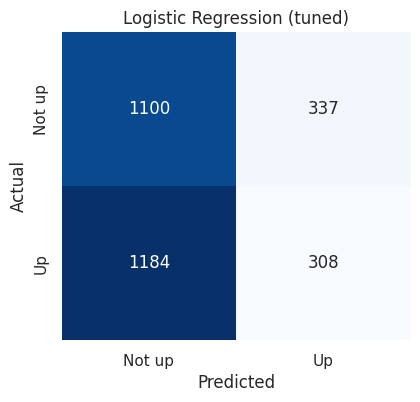

              precision    recall  f1-score   support

      Not up       0.48      0.77      0.59      1437
          Up       0.48      0.21      0.29      1492

    accuracy                           0.48      2929
   macro avg       0.48      0.49      0.44      2929
weighted avg       0.48      0.48      0.44      2929



In [47]:
final_model = log_reg_tuned
pred = final_model.predict(X_test)
cm = confusion_matrix(y_test, pred, labels=[0, 1])

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not up", "Up"], yticklabels=["Not up", "Up"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression (tuned)")
plt.show()

print(classification_report(y_test, pred, target_names=["Not up", "Up"], zero_division=0))

## Interpreting the coefficients

Each coefficient $\beta_j$ shifts the log-odds of an up day, and

$$\text{odds ratio}_j = e^{\beta_j}$$

is the multiplicative change in the odds for a one-unit increase in feature $j$ (after
scaling, one IQR above the median). Features share a common scale, so coefficient sizes
can be compared directly. Small coefficients should not be over-interpreted, since daily
direction is noisy.

,Feature,Coefficient,Odds ratio
0,Return,0.0626,1.0646
1,Log_Volume,0.0477,1.0489
2,Momentum_10,-0.0446,0.9563
3,HL_Range,0.0372,1.0379
4,MA20_Ratio,-0.0287,0.9717
5,MA5_Ratio,0.0218,1.0220
6,Return_Lag2,-0.0192,0.9810
7,Log_Volume_Change,0.0168,1.0169
8,Volatility_5,-0.0064,0.9936
9,Volatility_20,0.0027,1.0027


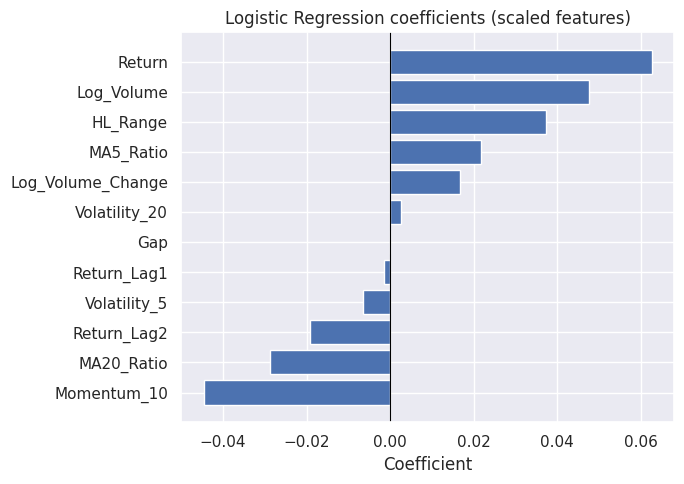

In [48]:
coefs = pd.DataFrame({
    "Feature": FEATURES,
    "Coefficient": final_model.coef_[0],
    "Odds ratio": np.exp(final_model.coef_[0]),
}).sort_values("Coefficient", key=abs, ascending=False).reset_index(drop=True)

display(coefs.round(4))

plt.figure(figsize=(7, 5))
plot_df = coefs.sort_values("Coefficient")
plt.barh(plot_df["Feature"], plot_df["Coefficient"])
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression coefficients (scaled features)")
plt.xlabel("Coefficient")
plt.tight_layout()
plt.show()

# Notes for the report

- **Target:** next-day direction (up vs not up), built from `Adj Close` returns.
- **Missing values:** the 2 empty rows were market holidays and were dropped, not forward filled.
- **Outliers:** none were removed. Extreme returns match real market events.
- **No leakage:** features use only past data, the split is chronological, the scaler is fit on the training set only, and `C` is tuned with a time-ordered cross-validation on the training set only.
- **Model:** logistic regression, compared against a majority-class baseline, with accuracy, precision, recall, F1 and ROC-AUC reported.
- **Limitation:** one stock, one split. A walk-forward evaluation on the test period would give a more reliable estimate.

# Data Analysis & Visualization

## Numerical data analysis

### Display the Summary of the DataFrame
`info()` function provides a concise summary of a DataFrame, displaying key details such as:
1. Data type of each column
2. RangeIndex (total number of rows)
3. List of columns
4. Count of non-null entries in each column
5. Overall memory usage of the DataFrame.

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14641 entries, 0 to 14640
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date               14641 non-null  datetime64[ns]
 1   Open               14641 non-null  float64       
 2   High               14641 non-null  float64       
 3   Low                14641 non-null  float64       
 4   Adj Close          14641 non-null  float64       
 5   Volume             14641 non-null  float64       
 6   Return             14641 non-null  float64       
 7   Log_Volume         14641 non-null  float64       
 8   Return_Lag1        14641 non-null  float64       
 9   Return_Lag2        14641 non-null  float64       
 10  MA5_Ratio          14641 non-null  float64       
 11  MA20_Ratio         14641 non-null  float64       
 12  Volatility_5       14641 non-null  float64       
 13  Volatility_20      14641 non-null  float64       
 14  Moment

### Display Descriptive Statistical Features of DataFrame
`.describe()` function gives a quick summary of the **numerical columns** in the DataFrame.

It shows the basic statistics like:
- Average
- Minimum
- Maximum
- Standard deviation

for the numbers in the table

In [50]:
df.describe()

,Date,Open,High,Low,Adj Close,Volume,Return,Log_Volume,Return_Lag1,Return_Lag2,MA5_Ratio,MA20_Ratio,Volatility_5,Volatility_20,Momentum_10,Log_Volume_Change,HL_Range,Gap,Target
count,14641,14641.000000,14641.000000,14641.000000,14641.000000,1.464100e+04,14641.000000,14641.000000,14641.000000,14641.000000,14641.000000,14641.000000,14641.000000,14641.000000,14641.000000,14641.000000,14641.000000,1.464100e+04,14641.000000
mean,1991-03-11 03:16:48.373744896,21.658325,21.890017,21.407868,21.656072,3.094525e+06,0.000630,14.232815,0.000626,0.000623,0.000983,0.004743,0.015774,0.017122,0.006269,0.000295,0.021869,4.055502e-04,0.480705
min,1962-01-31 00:00:00,0.106720,0.108070,0.106269,0.106720,1.520000e+04,-0.216216,9.629116,-0.216216,-0.216216,-0.210731,-0.332822,0.000000,0.004557,-0.371034,-2.946937,0.001883,-1.174606e-01,0.000000
25%,1976-09-15 00:00:00,0.568421,0.574351,0.562316,0.568479,4.664000e+05,-0.009109,13.052801,-0.009111,-0.009111,-0.010639,-0.022464,0.009416,0.012308,-0.029512,-0.315437,0.013021,-6.758803e-07,0.000000
50%,1991-03-11 00:00:00,1.494224,1.509811,1.478074,1.493355,2.309600e+06,0.000000,14.652585,0.000000,0.000000,0.000713,0.005608,0.013711,0.015734,0.005300,-0.016111,0.018692,0.000000e+00,0.000000
75%,2005-09-14 00:00:00,29.652029,29.970687,29.275233,29.632847,4.485200e+06,0.010126,15.316294,0.010124,0.010122,0.012575,0.033220,0.019567,0.020220,0.041131,0.303049,0.026651,9.583763e-04,1.000000
max,2020-03-31 00:00:00,164.258439,164.258439,160.557646,162.161331,6.778040e+07,0.147230,18.031784,0.147230,0.147230,0.148569,0.273862,0.129315,0.077275,0.392985,3.757861,0.315364,1.135063e-01,1.000000
std,NaN,34.904324,35.248698,34.522336,34.897059,3.414872e+06,0.018635,1.388457,0.018633,0.018626,0.021014,0.046081,0.009622,0.007231,0.059629,0.527677,0.013836,7.873890e-03,0.499645


## Visualizing the data

### Closing adjusted price over time

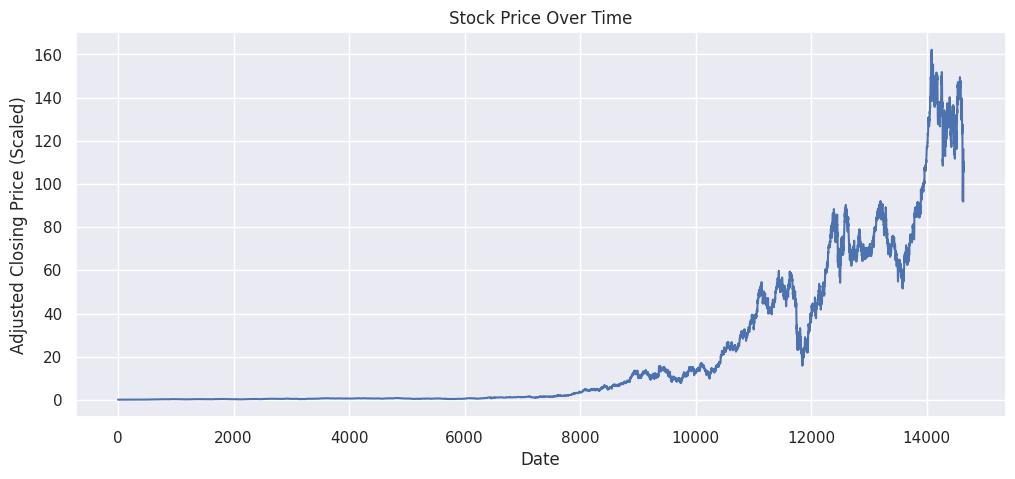

In [51]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Adj Close']) # Adjust 'df.index' if Date is a standard column
plt.xlabel('Date')
plt.ylabel('Adjusted Closing Price (Scaled)')
plt.title('Stock Price Over Time')
plt.show()

### Trading volume over time

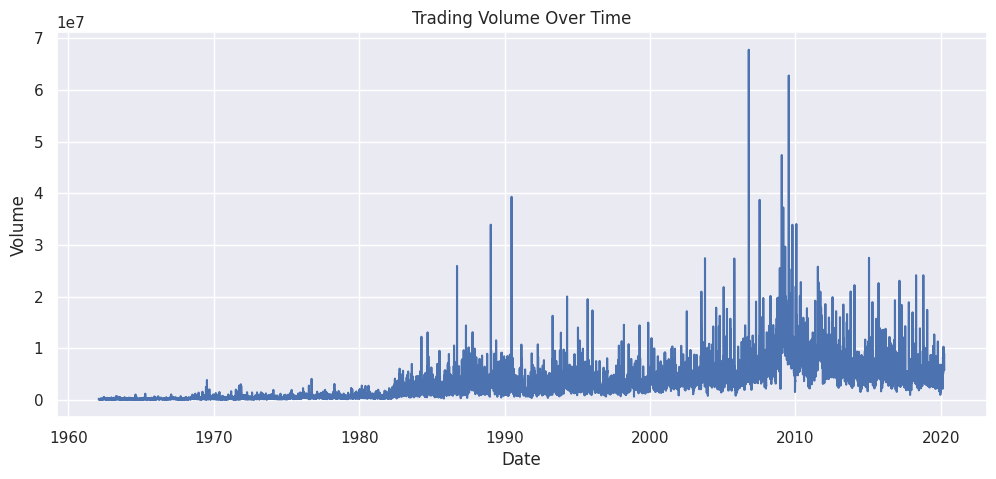

In [52]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Volume'])
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Trading Volume Over Time')
plt.show()

### Histogram

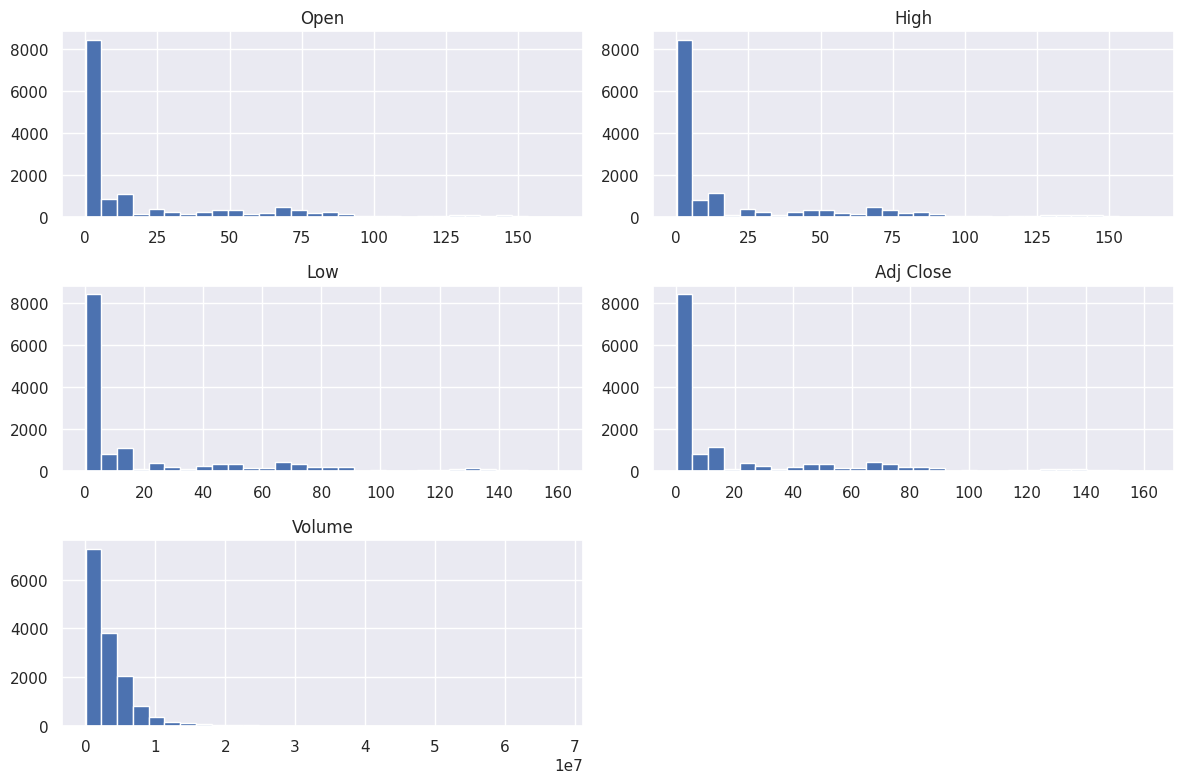

In [53]:
df[['Open','High','Low','Adj Close','Volume']].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

### Heatmap

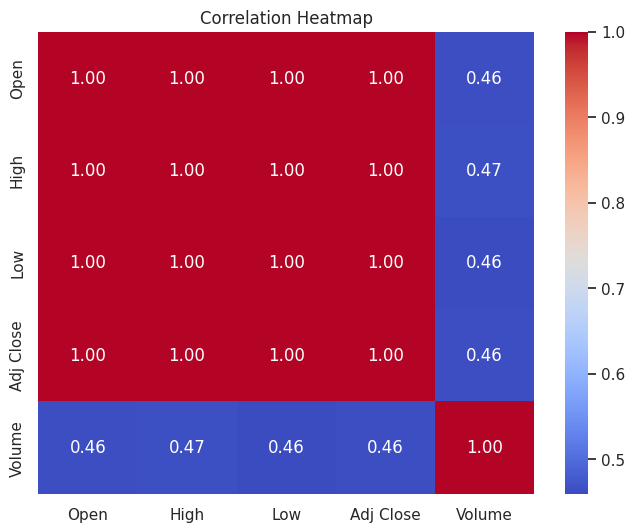

In [54]:
corr_cols = ['Open','High','Low','Adj Close','Volume']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

The correlation heatmap mathematically maps how strongly each feature in the dataset moves in relation to the others, measured on a scale from -1.00 to 1.00.

* **Extreme Price Multicollinearity:** The `Open`, `High`, `Low`, and `Adj Close` columns display near-perfect correlations between 0.99 and 1.00. This means they are essentially telling the model the exact same story; a high opening price inherently dictates a high maximum and closing price for that day.


* **Volume as a Unique Signal:** The `Volume` feature behaves differently, showing only a moderate positive correlation of 0.60 to 0.62 with the price metrics. This tells us that while higher trading volume generally aligns with higher stock prices, it acts as an independent variable that will provide the model with unique, non-redundant momentum data.


* **The Feature Engineering Mandate:** If we feed `Open`, `High`, and `Low` directly into a machine learning algorithm alongside the `Adj Close` target, the model will struggle with severe multicollinearity. It cannot isolate distinct predictive patterns when all the inputs are virtually identical. This visualization is the exact proof we need to justify why we must engineer new, derived features—like Moving Averages or Daily Returns—to give the algorithm actual market trends to learn from.